# Virality Prediction Engine

## Objective
To develop a data-driven Viral Score that gives greater importance to
high-value user actions such as shares and saves, while also considering
likes and comments.

The score will be used to identify high-potential content and analyze
which platforms, categories, and content formats are associated with
stronger viral performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "cleaned_social_media_engagement_dataset.csv",
    parse_dates=["Timestamp"]
)

df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified,Month,Total_Interactions
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False,2024-01,8605
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True,2024-01,2124
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True,2024-01,2084
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False,2024-01,1886
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False,2024-01,10470


In [3]:
print("Dataset Shape:", df.shape)
print("Timestamp Type:", df["Timestamp"].dtype)

df.columns.tolist()

Dataset Shape: (5000, 22)
Timestamp Type: datetime64[ns]


['Post_ID',
 'Timestamp',
 'Platform',
 'Content_Type',
 'Category',
 'Likes',
 'Comments',
 'Shares',
 'Views',
 'Saves',
 'Follower_Count',
 'Engagement_Rate',
 'Hour_of_Day',
 'Day_of_Week',
 'Hashtag_Count',
 'Content_Length',
 'Sentiment',
 'Influencer_Tier',
 'Has_Media',
 'Is_Verified',
 'Month',
 'Total_Interactions']

### Interaction Rates

Raw engagement counts are influenced by the number of views a post receives.
Therefore, interaction metrics are converted into rates relative to views
before calculating the Viral Score.

In [4]:
df["Like_Rate"] = (df["Likes"] / df["Views"]) * 100
df["Comment_Rate"] = (df["Comments"] / df["Views"]) * 100
df["Share_Rate"] = (df["Shares"] / df["Views"]) * 100
df["Save_Rate"] = (df["Saves"] / df["Views"]) * 100

In [5]:
df[
    [
        "Post_ID",
        "Views",
        "Likes",
        "Like_Rate",
        "Comments",
        "Comment_Rate",
        "Shares",
        "Share_Rate",
        "Saves",
        "Save_Rate"
    ]
].head()

,Post_ID,Views,Likes,Like_Rate,Comments,Comment_Rate,Shares,Share_Rate,Saves,Save_Rate
0,POST_04552,29502,8287,28.089621,247,0.837231,51,0.172870,20,0.067792
1,POST_02171,24538,1711,6.972858,27,0.110033,247,1.006602,139,0.566468
2,POST_00210,5460,1527,27.967033,191,3.498168,7,0.128205,359,6.575092
3,POST_01548,68246,535,0.783929,178,0.260821,433,0.634469,740,1.084313
4,POST_01350,25782,9706,37.646420,35,0.135754,118,0.457684,611,2.369870


In [6]:
rate_cols = [
    "Like_Rate",
    "Comment_Rate",
    "Share_Rate",
    "Save_Rate"
]

df[rate_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Like_Rate,5000.0,24.696681,66.967546,0.012336,3.641421,8.816813,21.141950,1809.981851
Comment_Rate,5000.0,1.186720,2.866658,0.001494,0.187142,0.450888,1.050215,66.063348
Share_Rate,5000.0,2.638021,6.440995,0.001406,0.400043,0.996739,2.292235,111.918850
Save_Rate,5000.0,2.476825,6.191611,0.004092,0.404996,0.907539,2.108695,136.191261


In [7]:
for col in rate_cols:
    print(
        col,
        "above 100%:",
        (df[col] > 100).sum()
    )

Like_Rate above 100%: 212
Comment_Rate above 100%: 0
Share_Rate above 100%: 2
Save_Rate above 100%: 2


**Data Quality Note:**  
Some interaction-to-view rates exceed 100%, particularly the Like Rate.
This indicates that view counts are not consistently comparable with interaction
counts across all records or platforms. Therefore, view-normalized rates are
retained only for diagnostic analysis and are not used directly in the final
Viral Score.

### Platform-Relative Normalization

Since engagement scales differ across social media platforms, each interaction
metric is converted into a percentile rank within its respective platform.

This allows posts to be evaluated relative to typical performance on the same
platform instead of directly comparing raw interaction counts across platforms.

In [8]:
# Rank engagement actions relative to other posts on the same platform

df["Like_Score"] = (
    df.groupby("Platform")["Likes"]
      .rank(pct=True)
)

df["Comment_Score"] = (
    df.groupby("Platform")["Comments"]
      .rank(pct=True)
)

df["Share_Score"] = (
    df.groupby("Platform")["Shares"]
      .rank(pct=True)
)

df["Save_Score"] = (
    df.groupby("Platform")["Saves"]
      .rank(pct=True)
)

### Viral Score Design

The project specification emphasizes that shares and saves should carry
greater importance than passive likes.

The following weights are therefore used:

- Likes: 15%
- Comments: 15%
- Shares: 35%
- Saves: 35%

These weights are a project design choice and can be adjusted during
future model calibration.

In [9]:
df["Viral_Score"] = (
    0.15 * df["Like_Score"]
    + 0.15 * df["Comment_Score"]
    + 0.35 * df["Share_Score"]
    + 0.35 * df["Save_Score"]
) * 100

In [10]:
df[
    [
        "Post_ID",
        "Platform",
        "Content_Type",
        "Category",
        "Viral_Score"
    ]
].head()

,Post_ID,Platform,Content_Type,Category,Viral_Score
0,POST_04552,Instagram,Carousel,Business,26.543258
1,POST_02171,LinkedIn,Document,Health,49.765936
2,POST_00210,Instagram,Carousel,Food,20.874903
3,POST_01548,Facebook,Video,Sports,55.475102
4,POST_01350,Instagram,Photo,Fitness,50.670304


In [11]:
df["Viral_Score"].describe()

count    5000.000000
mean       50.060000
std        15.857832
min         3.462907
25%        38.724203
50%        49.902634
75%        61.315558
max        94.387450
Name: Viral_Score, dtype: float64

In [12]:
df["Viral_Level"] = pd.qcut(
    df["Viral_Score"],
    q=[0, 0.50, 0.80, 0.95, 1.00],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [13]:
df["Viral_Level"].value_counts()

Viral_Level
Low          2500
Moderate     1500
High          750
Very High     250
Name: count, dtype: int64

In [14]:
top_viral_posts = df.nlargest(
    10,
    "Viral_Score"
)[
    [
        "Post_ID",
        "Platform",
        "Content_Type",
        "Category",
        "Likes",
        "Comments",
        "Shares",
        "Saves",
        "Views",
        "Viral_Score",
        "Viral_Level"
    ]
]

top_viral_posts

,Post_ID,Platform,Content_Type,Category,Likes,Comments,Shares,Saves,Views,Viral_Score,Viral_Level
1788,POST_03453,LinkedIn,Post,Fitness,1977,139,460,291,7498,94.387450,Very High
3400,POST_03167,YouTube,Community Post,Lifestyle,15360,951,1977,4694,638606,93.225470,Very High
1540,POST_04655,Twitter,Tweet,Business,3821,257,1936,496,74490,93.166499,Very High
3302,POST_01361,YouTube,Video,Fashion,13134,936,1980,4848,267404,92.593946,Very High
3282,POST_02861,TikTok,Video,Food,46835,1819,4929,2628,97881,92.229551,Very High
4362,POST_00857,Instagram,Reel,Sports,8188,391,290,972,8663,92.071317,Very High
1262,POST_03974,LinkedIn,Poll,Travel,1535,147,442,292,1515,90.796813,Very High
3961,POST_04228,Facebook,Story,Fitness,7361,351,984,650,25219,90.551321,Very High
1803,POST_03329,Instagram,Carousel,Food,7088,410,294,915,24986,89.353079,Very High
125,POST_01783,Facebook,Post,Sports,7406,273,937,728,20661,89.270833,Very High


**Observation:**  
The highest Viral Scores are observed across multiple platforms and content
formats, indicating that the platform-relative scoring method prevents platforms
with naturally larger interaction counts from dominating the ranking.

Posts classified as "Very High" represent the top 5% of Viral Scores in the
dataset. The Viral Score measures performance relative to typical content on
the same platform, with greater weight assigned to shares and saves.

### Viral Score Distribution

This analysis examines how Viral Scores are distributed across the complete dataset.

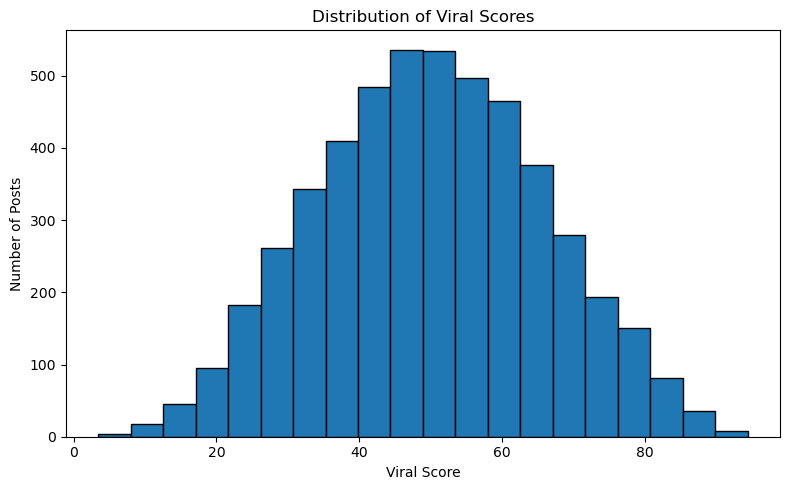

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Viral_Score"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Viral Scores")
plt.xlabel("Viral Score")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

**Observation:**  
The Viral Score distribution is approximately centered around 50, with most
posts receiving moderate scores and relatively few posts appearing at the
extreme low or high ends. This indicates that the platform-relative scoring
method produces a balanced spread of virality scores.

### High-Virality Classification

Posts belonging to the "High" or "Very High" Viral Level are treated as
high-virality posts for further analysis.

In [16]:
df["Is_High_Viral"] = df["Viral_Level"].isin(
    ["High", "Very High"]
)

df["Is_High_Viral"].value_counts()

Is_High_Viral
False    4000
True     1000
Name: count, dtype: int64

### High-Virality Rate by Content Category

Instead of comparing only average Viral Scores, this analysis measures the
percentage of posts within each category that fall into the High or Very High
virality groups.

In [17]:
category_virality = (
    df.groupby("Category")
      .agg(
          Total_Posts=("Post_ID", "count"),
          High_Viral_Posts=("Is_High_Viral", "sum"),
          Median_Viral_Score=("Viral_Score", "median")
      )
)

category_virality["High_Viral_Rate"] = (
    category_virality["High_Viral_Posts"]
    / category_virality["Total_Posts"]
) * 100

category_virality = category_virality.sort_values(
    "High_Viral_Rate",
    ascending=False
)

category_virality.round(2)

,Total_Posts,High_Viral_Posts,Median_Viral_Score,High_Viral_Rate
Category,,,,
Sports,401,92,51.26,22.94
Food,413,91,51.03,22.03
Fashion,428,94,49.63,21.96
Lifestyle,433,94,50.20,21.71
Fitness,393,83,49.21,21.12
Technology,434,89,49.60,20.51
Health,397,75,49.26,18.89
Business,382,72,49.42,18.85
Entertainment,432,81,48.18,18.75


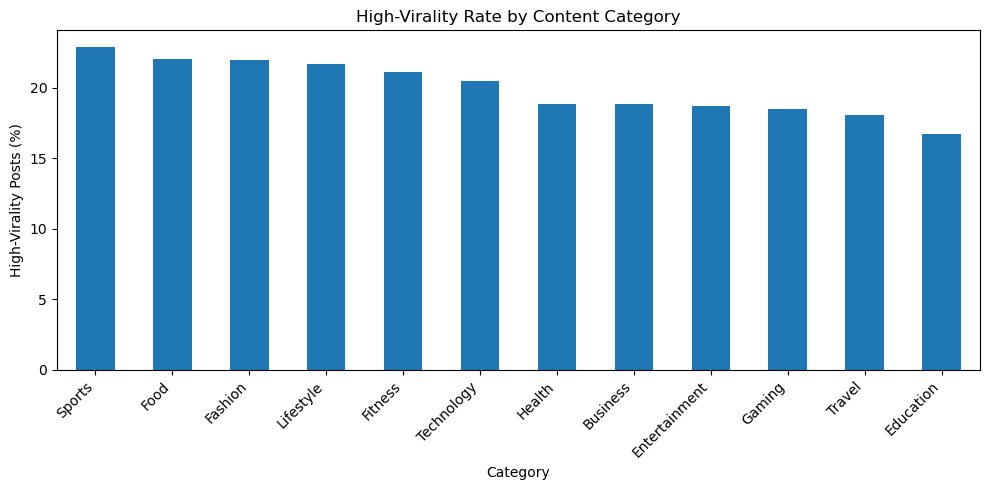

In [18]:
category_virality["High_Viral_Rate"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("High-Virality Rate by Content Category")
plt.xlabel("Category")
plt.ylabel("High-Virality Posts (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:**  
Sports has the highest high-virality rate at approximately 22.94%, followed
by Food (22.03%) and Fashion (21.96%). Education records the lowest rate at
approximately 16.71%.

The differences across categories are moderate, suggesting that content topic
has some relationship with viral performance but does not determine virality
on its own.

### High-Virality Rate by Content Type

This analysis identifies which content formats most frequently appear in
the High or Very High virality groups.

In [19]:
content_virality = (
    df.groupby("Content_Type")
      .agg(
          Total_Posts=("Post_ID", "count"),
          High_Viral_Posts=("Is_High_Viral", "sum"),
          Median_Viral_Score=("Viral_Score", "median")
      )
)

content_virality["High_Viral_Rate"] = (
    content_virality["High_Viral_Posts"]
    / content_virality["Total_Posts"]
) * 100

content_virality = content_virality.sort_values(
    "High_Viral_Rate",
    ascending=False
)

content_virality.round(2)

,Total_Posts,High_Viral_Posts,Median_Viral_Score,High_Viral_Rate
Content_Type,,,,
Reel,306,72,50.47,23.53
Story,568,132,50.49,23.24
Community Post,135,31,52.39,22.96
Duet,248,53,49.75,21.37
Document,132,28,53.16,21.21
Tweet,239,49,49.03,20.50
Thread,236,47,49.17,19.92
Photo,320,63,47.53,19.69
Post,378,73,49.75,19.31


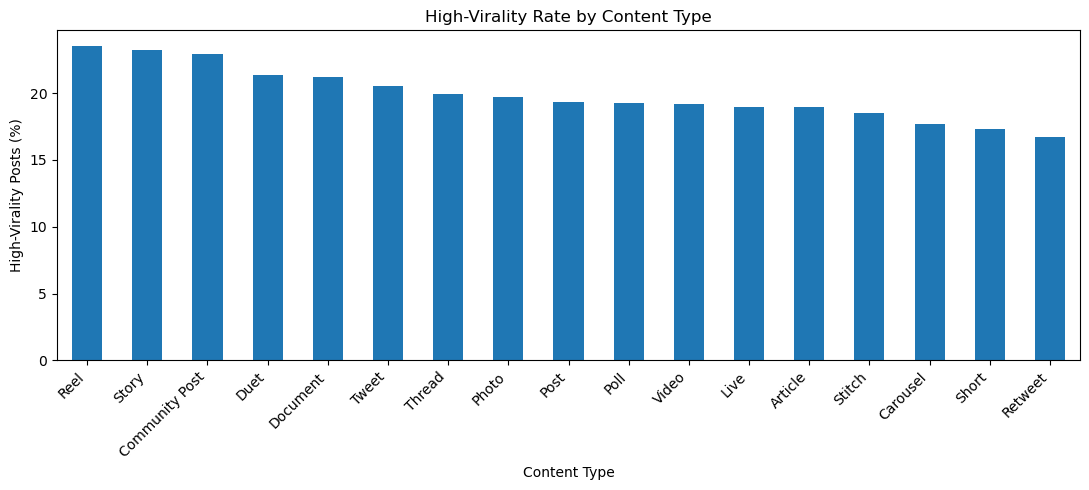

In [20]:
content_virality["High_Viral_Rate"].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("High-Virality Rate by Content Type")
plt.xlabel("Content Type")
plt.ylabel("High-Virality Posts (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:**  
Reels show the highest high-virality rate at approximately 23.53%, closely
followed by Stories (23.24%) and Community Posts (22.96%). Retweets record
the lowest high-virality rate at approximately 16.73%.

This indicates that some content formats appear more frequently in the
high-virality group, although virality is influenced by multiple factors.

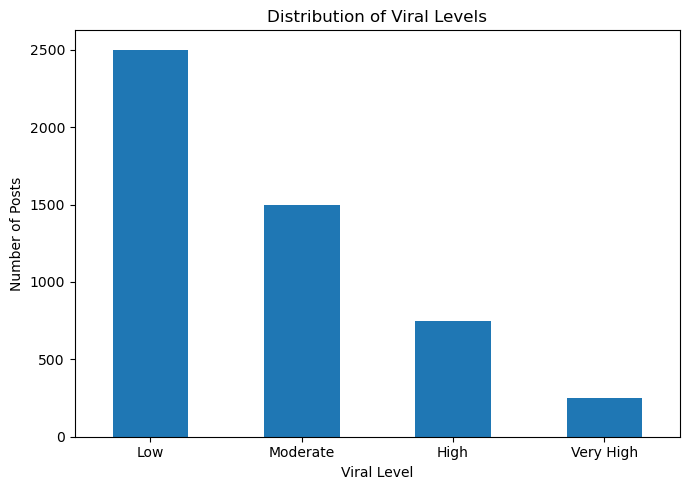

In [21]:
viral_level_order = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

viral_level_counts = (
    df["Viral_Level"]
      .value_counts()
      .reindex(viral_level_order)
)

viral_level_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Viral Levels")
plt.xlabel("Viral Level")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**  
The Viral Level groups contain 2,500 Low, 1,500 Moderate, 750 High, and
250 Very High posts. These proportions are expected because the groups were
defined using percentile-based thresholds. High and Very High posts together
represent the top 20% of the dataset.

## Machine Learning Virality Prediction

The Viral Score measures observed performance after a post has received
engagement. The next step is to build a machine learning model that predicts
whether a post is likely to achieve High or Very High virality using features
that can be known before or at the time of publishing.

Engagement outcome variables such as Likes, Comments, Shares, Saves, Views,
Engagement Rate, and Viral Score are excluded from the predictors to prevent
data leakage.

In [22]:
# Convert True/False into 1/0 for machine learning

df["High_Viral_Target"] = df["Is_High_Viral"].astype(int)

df["High_Viral_Target"].value_counts()

High_Viral_Target
0    4000
1    1000
Name: count, dtype: int64

In [23]:
features = [
    "Platform",
    "Content_Type",
    "Category",
    "Hour_of_Day",
    "Day_of_Week",
    "Hashtag_Count",
    "Content_Length",
    "Sentiment",
    "Influencer_Tier",
    "Has_Media",
    "Is_Verified"
]

X = df[features]
y = df["High_Viral_Target"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5000, 11)
y Shape: (5000,)


In [24]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Encoded Shape:", X_encoded.shape)
X_encoded.head()

Encoded Shape: (5000, 48)


,Hour_of_Day,Hashtag_Count,Content_Length,Has_Media,Is_Verified,Platform_Instagram,Platform_LinkedIn,Platform_TikTok,Platform_Twitter,Platform_YouTube,Content_Type_Carousel,Content_Type_Community Post,Content_Type_Document,Content_Type_Duet,Content_Type_Live,Content_Type_Photo,Content_Type_Poll,Content_Type_Post,Content_Type_Reel,Content_Type_Retweet,Content_Type_Short,Content_Type_Stitch,Content_Type_Story,Content_Type_Thread,Content_Type_Tweet,Content_Type_Video,Category_Education,Category_Entertainment,Category_Fashion,Category_Fitness,Category_Food,Category_Gaming,Category_Health,Category_Lifestyle,Category_Sports,Category_Technology,Category_Travel,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Sentiment_Neutral,Sentiment_Positive,Influencer_Tier_Micro,Influencer_Tier_Mid-tier,Influencer_Tier_Nano
0,1,16,985,True,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,5,9,627,False,True,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,9,27,79,True,True,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
3,10,17,554,True,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0
4,13,5,1136,True,False,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training rows: 4000
Testing rows: 1000

Training target distribution:
High_Viral_Target
0    3200
1     800
Name: count, dtype: int64

Testing target distribution:
High_Viral_Target
0    800
1    200
Name: count, dtype: int64


### Random Forest Classifier

A Random Forest classifier is trained to predict whether a post is likely
to belong to the High or Very High virality group.

Class balancing is used because only 20% of the posts belong to the
high-virality class.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Model Predictions

In [27]:
y_pred = rf_model.predict(X_test)

y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Model Evaluation

Accuracy alone can be misleading because the target classes are imbalanced.
Therefore, Precision, Recall and F1 Score are also evaluated.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.797
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       800
           1       0.00      0.00      0.00       200

    accuracy                           0.80      1000
   macro avg       0.40      0.50      0.44      1000
weighted avg       0.64      0.80      0.71      1000



**Observation:**  
Although the Random Forest achieves approximately 79.7% accuracy, this result
is misleading because 80% of the test observations belong to the non-high-viral
class.

The model fails to correctly identify any High-Viral posts, resulting in
Precision, Recall, and F1 Score values of 0 for the positive class.

Therefore, accuracy alone is not an appropriate measure of model performance
for this imbalanced classification problem.

### Confusion Matrix

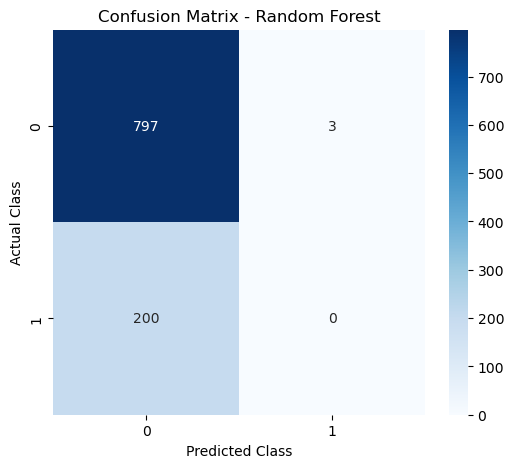

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

**Observation:**  
The confusion matrix shows that the model correctly classified 797 non-high-viral
posts but failed to identify all 200 actual high-viral posts.

This indicates that the model is strongly biased toward the majority class and
is not currently suitable for reliable high-virality prediction.

In [30]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.521


**Observation:**  
The ROC-AUC score of 0.521 is only slightly above random guessing (0.50).
This suggests that the available pre-publication features do not contain enough
predictive information to reliably distinguish high-viral posts from other posts.

### Baseline Model Comparison

A simple majority-class baseline is used to determine whether the Random Forest
performs better than simply predicting every post as non-high-viral.

In [31]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy     :", round(baseline_accuracy, 3))
print("Random Forest Accuracy:", round(accuracy, 3))

Baseline Accuracy     : 0.8
Random Forest Accuracy: 0.797


### Predicted Probability Analysis

The predicted probabilities are examined to determine whether the model assigns
meaningful high-virality probabilities even when the final predicted class is 0.

In [32]:
pd.Series(y_prob).describe()

count    1000.000000
mean        0.208227
std         0.075219
min         0.036667
25%         0.153333
50%         0.200000
75%         0.250000
max         0.643333
dtype: float64

In [33]:
print("Predictions with probability >= 0.50:",
      (y_prob >= 0.50).sum())

print("Predictions with probability >= 0.40:",
      (y_prob >= 0.40).sum())

print("Predictions with probability >= 0.30:",
      (y_prob >= 0.30).sum())

Predictions with probability >= 0.50: 3
Predictions with probability >= 0.40: 17
Predictions with probability >= 0.30: 115


### Feature Importance

Feature importance is examined to understand which pre-publication attributes
the Random Forest relied on most while making predictions.

In [34]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

feature_importance.head(15)

Content_Length              0.162935
Hashtag_Count               0.131709
Hour_of_Day                 0.126323
Is_Verified                 0.025674
Sentiment_Positive          0.024914
Sentiment_Neutral           0.023108
Has_Media                   0.020898
Day_of_Week_Tuesday         0.018556
Day_of_Week_Wednesday       0.017873
Day_of_Week_Saturday        0.017856
Day_of_Week_Thursday        0.017488
Day_of_Week_Monday          0.017109
Influencer_Tier_Mid-tier    0.016167
Day_of_Week_Sunday          0.015797
Platform_Instagram          0.015390
dtype: float64

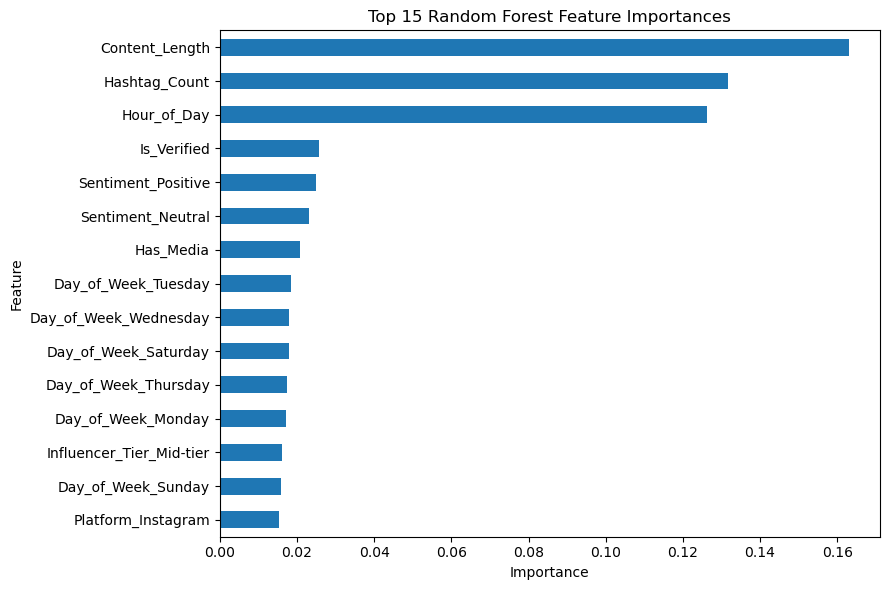

In [35]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Model Improvement Attempt

The initial Random Forest model showed poor detection of high-virality posts.
Therefore, additional pre-publication features are engineered and a second
classification algorithm is evaluated.

The objective is to improve Recall, F1 Score, and ROC-AUC rather than relying
only on overall accuracy.

In [36]:
df["Is_Weekend"] = df["Day_of_Week"].isin(
    ["Saturday", "Sunday"]
).astype(int)

df["Time_Period"] = pd.cut(
    df["Hour_of_Day"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=[
        "Late Night",
        "Morning",
        "Afternoon",
        "Evening",
        "Night"
    ]
)

df[
    [
        "Hour_of_Day",
        "Time_Period",
        "Day_of_Week",
        "Is_Weekend"
    ]
].head()

,Hour_of_Day,Time_Period,Day_of_Week,Is_Weekend
0,1,Late Night,Monday,0
1,5,Late Night,Monday,0
2,9,Morning,Monday,0
3,10,Morning,Monday,0
4,13,Afternoon,Monday,0


### Improved Feature Set

Additional timing information is included while continuing to exclude
post-performance variables such as Likes, Shares, Saves, Views,
Engagement Rate, and Viral Score.

In [37]:
improved_features = [
    "Platform",
    "Content_Type",
    "Category",
    "Hour_of_Day",
    "Time_Period",
    "Day_of_Week",
    "Is_Weekend",
    "Hashtag_Count",
    "Content_Length",
    "Sentiment",
    "Influencer_Tier",
    "Has_Media",
    "Is_Verified"
]

X2 = df[improved_features]
y2 = df["High_Viral_Target"]

print("Improved X Shape:", X2.shape)
print("Target Shape:", y2.shape)

Improved X Shape: (5000, 13)
Target Shape: (5000,)


In [38]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

print("Training rows:", X2_train.shape[0])
print("Testing rows:", X2_test.shape[0])

Training rows: 4000
Testing rows: 1000


### Preprocessing

Categorical features are one-hot encoded and numerical features are standardized
before training the Logistic Regression model.

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "Hour_of_Day",
    "Is_Weekend",
    "Hashtag_Count",
    "Content_Length"
]

categorical_features = [
    "Platform",
    "Content_Type",
    "Category",
    "Time_Period",
    "Day_of_Week",
    "Sentiment",
    "Influencer_Tier",
    "Has_Media",
    "Is_Verified"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

### Balanced Logistic Regression

A Logistic Regression classifier with balanced class weights is used to give
greater importance to the minority high-virality class.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

log_model.fit(
    X2_train,
    y2_train
)

print("Balanced Logistic Regression trained successfully.")

Balanced Logistic Regression trained successfully.


In [41]:
log_pred = log_model.predict(X2_test)

log_prob = log_model.predict_proba(
    X2_test
)[:, 1]

log_accuracy = accuracy_score(
    y2_test,
    log_pred
)

log_precision = precision_score(
    y2_test,
    log_pred
)

log_recall = recall_score(
    y2_test,
    log_pred
)

log_f1 = f1_score(
    y2_test,
    log_pred
)

log_auc = roc_auc_score(
    y2_test,
    log_prob
)

print("Accuracy :", round(log_accuracy, 3))
print("Precision:", round(log_precision, 3))
print("Recall   :", round(log_recall, 3))
print("F1 Score :", round(log_f1, 3))
print("ROC-AUC  :", round(log_auc, 3))

Accuracy : 0.519
Precision: 0.21
Recall   : 0.51
F1 Score : 0.298
ROC-AUC  : 0.508


In [42]:
print(
    classification_report(
        y2_test,
        log_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.52      0.63       800
           1       0.21      0.51      0.30       200

    accuracy                           0.52      1000
   macro avg       0.51      0.52      0.47      1000
weighted avg       0.69      0.52      0.57      1000



**Observation:**  
The balanced Logistic Regression model improves the recall of the high-virality
class from 0.00 to 0.51, meaning that it successfully identifies approximately
half of the actual high-virality posts.

However, its precision remains low at 0.21 and the ROC-AUC score is only 0.508,
which is close to random classification. Therefore, the improvement in recall
does not represent strong overall predictive performance.

The results suggest that the available pre-publication metadata does not contain
sufficient information to reliably predict whether a post will achieve high
virality.

## Virality Prediction Conclusion

Two machine learning approaches were evaluated for pre-publication virality
prediction.

The Random Forest model achieved high apparent accuracy but failed to identify
high-virality posts. Balanced Logistic Regression improved minority-class recall
but still produced an ROC-AUC close to random classification.

Therefore, the final Virality Engine relies primarily on the platform-relative
Viral Score, which incorporates actual audience interaction signals and gives
greater weight to Shares and Saves. The machine learning experiment is retained
as evidence that content metadata alone is insufficient for reliable advance
virality prediction in the available dataset.

In [43]:
virality_output = df[
    [
        "Post_ID",
        "Platform",
        "Content_Type",
        "Category",
        "Likes",
        "Comments",
        "Shares",
        "Views",
        "Saves",
        "Engagement_Rate",
        "Viral_Score",
        "Viral_Level",
        "Is_High_Viral"
    ]
].copy()

virality_output.to_csv(
    "social_media_virality_analysis.csv",
    index=False
)

print("Virality dataset saved successfully.")
print("Shape:", virality_output.shape)

Virality dataset saved successfully.
Shape: (5000, 13)


In [44]:
import zipfile

with zipfile.ZipFile("virality_data.zip", "w") as zipf:
    zipf.write("social_media_virality_analysis.csv")

print("ZIP created successfully.")

ZIP created successfully.
